<a href="https://colab.research.google.com/github/emmagiometti/A2026_Intro_Python/blob/main/1_4_env_excercise_matplotlib_and_xarray.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> Notebook-friendly copy of `part-I/1.4-matplotlib-and-xarray-environmental-exercises.ipynb`, generated by `tools/make_live.py`. Edit the book notebook, not this file.

In [49]:
# --- environment setup (generated, not part of the lesson) ---
# Colab and Kaggle do not ship every package this notebook imports.
# This is a no-op in an environment that is already set up.
import importlib.util
import subprocess
import sys

for module, package in {"pooch": "pooch"}.items():
    if importlib.util.find_spec(module) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

# Environmental Exercises

**ℹ️ How to use these exercises**

Attempt each from scratch in the empty code cell. Run the setup cell below first. Label every axis with its unit.

Exercise 1 works on a real global-temperature record, and the last four exercises work differently: each shows a figure made from a real dataset and asks you to rebuild it. Get as close as you can, and read the hints one at a time rather than all at once.

In [50]:
# Pre-supplied: run this first.
import numpy as np
import matplotlib.pyplot as plt

## Exercise 1: NASA's real global-temperature record

The file cached below is NASA GISS's monthly global-mean surface temperature anomaly (°C,
relative to a 1951–1980 baseline), one row per year since 1880, one column per calendar month.
A handful of recent months are still missing, marked `***`.

Wrap the twelve month columns in an xarray `DataArray` with dims `("year", "month")` and a `units`
attribute, then draw two figures: the annual mean as a line against year, and the full
`(year, month)` array with xarray's own `.plot()`. In a comment, compare what the warming trend
looks like read month by month against the single annual line.

In [51]:
# Pre-supplied: download the data file and cache it locally.
import pooch

path = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/nasa_gistemp_global_temp_anomaly.csv",
    known_hash="sha256:6cfa44e7bbacd9b12cb10bdd64b3182c2735fa3f3a95688e1f7bc8e5dfcece93",
    fname="nasa_gistemp_global_temp_anomaly.csv",
    path=pooch.os_cache("mlees"),
)

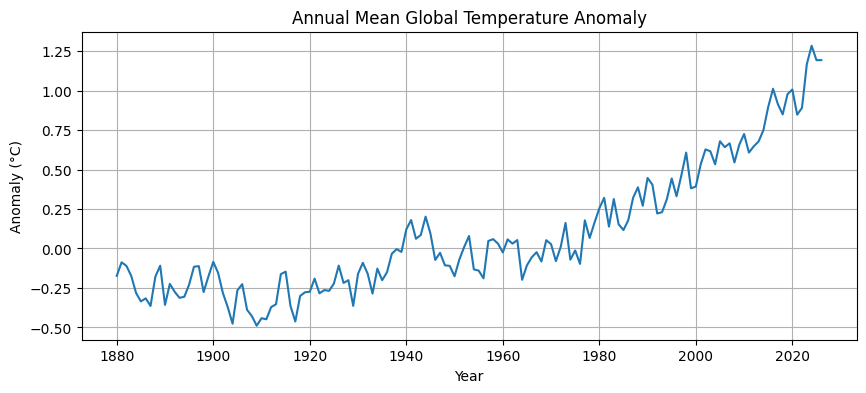

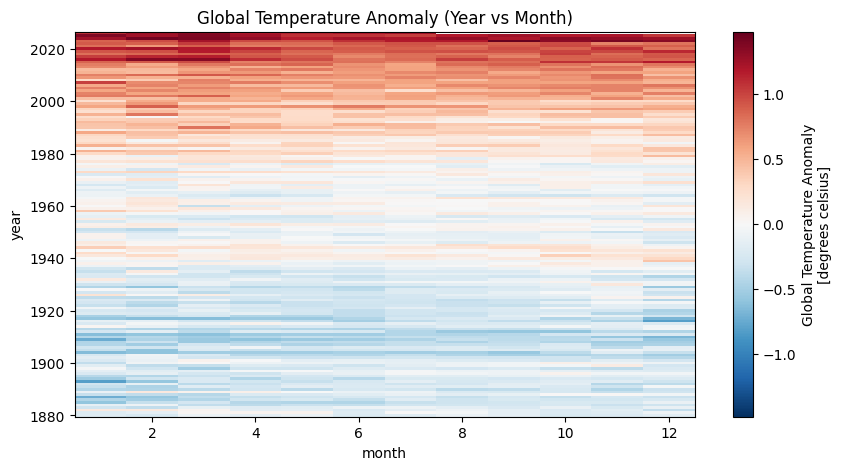

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# 1. Load the dataset using genfromtxt
data = np.genfromtxt(
    path,
    skip_header=1,
    delimiter=",",
    names=True,
    missing_values="***",
    filling_values=np.nan
)

# 2. Extract and stack the 12 monthly columns side-by-side
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
stacked = np.column_stack([data[m] for m in months])

# 3. Wrap months in an xarray DataArray
da = xr.DataArray(
    stacked,
    dims=("year", "month"),
    coords={
        "year": data["Year"],
        "month": np.arange(1, 13)
    },
    attrs={
        "long_name": "Global Temperature Anomaly",
        "units": "degrees celsius"
    }
)

# 4. Plot the annual mean as a line against year
plt.figure(figsize=(10, 4))
da.mean(dim="month").plot()
plt.title("Annual Mean Global Temperature Anomaly")
plt.ylabel("Anomaly (°C)")
plt.xlabel("Year")
plt.grid(True)
plt.show()

# 5. Plot the full 2D array using xarray's own .plot() (pcolormesh)
plt.figure(figsize=(10, 5))
da.plot()
plt.title("Global Temperature Anomaly (Year vs Month)")
plt.show()

# Comparison comment:
# The annual mean line shows a distinct long-term warming trend since the 1970s.
# Looking at the 2D month-by-month grid, we can observe fine-grained natural variability
# and extreme warm/cold months, but the overall transition from blue (colder) to red (warmer)
# over time is still extremely prominent.

## Replicating plots

The four exercises below each show a figure built from a real dataset and ask you to rebuild it
as closely as you can. The data arrive through a pre-supplied `pooch` cell; everything after that
is yours.

Work towards the target one element at a time — get the data onto the axes first, then the
coordinates, then the colours, then the labels — rather than trying to write the whole cell in
one go.

## Exercise 2: Global surface air temperature and its zonal mean

The three files cached below hold one snapshot of surface air temperature from the
[NCEP/NCAR atmospheric reanalysis 1](https://psl.noaa.gov/data/gridded/data.ncep.reanalysis.html),
as plain numpy arrays: `lon` (192 longitudes), `lat` (94 latitudes, running north to south), and
`temp_kelvin`, the field itself with shape `(94, 192)` — **in kelvin**.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.4-target-global-temperature.png" alt="A filled contour map of global surface air temperature in magma colours with a white dashed contour at minus ten degrees, beside a line plot of the zonal mean against latitude" width="100%">

<em>The figure to replicate. Left: the field as filled contours, with a single white contour drawn
at −10 °C. Right: the zonal mean — the average along longitude — against latitude.</em>


Rebuild it, and say in a comment which hemisphere's winter this snapshot was taken in, and how
the zonal mean tells you.

In [53]:
# Pre-supplied: download the three arrays and cache them locally.
import pooch

In [54]:
base_url = "https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/"

In [55]:
path_lon = pooch.retrieve(
    url=base_url + "ncep_global_temp_lon.npy",
    known_hash="sha256:eaf54b88dd89279d3034da17fe8470dc2c841bf9fa89b2aa741dacff9c326cdb",
    fname="ncep_global_temp_lon.npy",
    path=pooch.os_cache("mlees"),
)
path_lat = pooch.retrieve(
    url=base_url + "ncep_global_temp_lat.npy",
    known_hash="sha256:af1f438080460e1fca4583b2ec19b44285a3d3776e4d21b8da9b6e162906c88a",
    fname="ncep_global_temp_lat.npy",
    path=pooch.os_cache("mlees"),
)
path_temp = pooch.retrieve(
    url=base_url + "ncep_global_temp_kelvin.npy",
    known_hash="sha256:e040ca257334708b43e86398e09a5669fcf051179ecf5dcd278f758d67beed20",
    fname="ncep_global_temp_kelvin.npy",
    path=pooch.os_cache("mlees"),
)

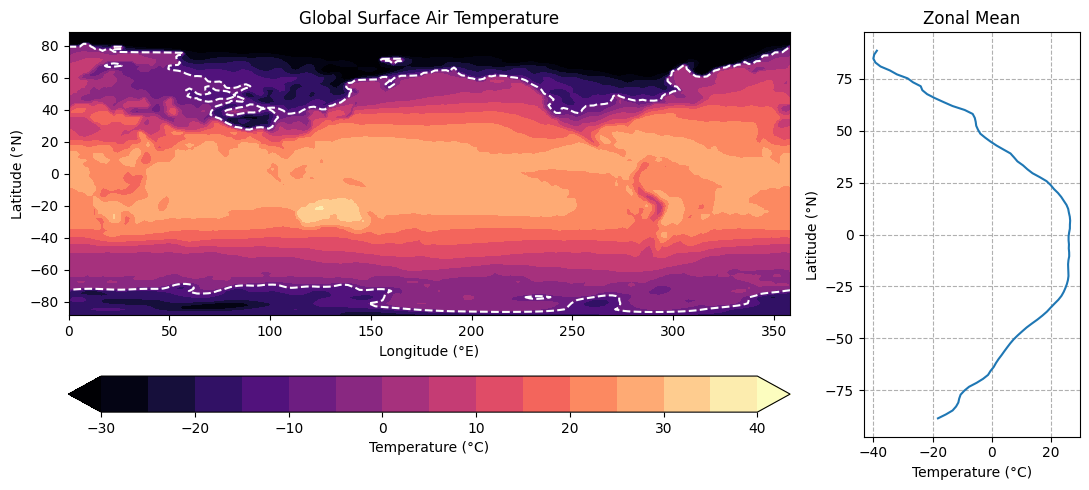

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Load the datasets
longitude = np.load(path_lon)
latitude = np.load(path_lat)
tempk = np.load(path_temp)

# Convert Kelvin to Celsius
tempc = tempk - 273.15

# Set up the figure and axes
fig, axes = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={"width_ratios": [5, 1.5]})

# Left panel: Filled contour plot
contour_plot = axes[0].contourf(longitude, latitude, tempc, cmap="magma", levels=np.linspace(-30, 40, 15), extend="both")

# Highlight the -10 degrees Celsius isotherm with a dashed white contour
axes[0].contour(longitude, latitude, tempc, levels=[-10], colors="w", linestyles="dashed") #setting contour line
axes[0].set_title("Global Surface Air Temperature")
axes[0].set_xlabel("Longitude (°E)")
axes[0].set_ylabel("Latitude (°N)")

# Add colorbar for the contour plot
cbar = fig.colorbar(contour_plot, ax=axes[0], orientation="horizontal", pad=0.15)
cbar.set_label("Temperature (°C)")

# second plot: Zonal mean against latitude
zonal_mean = np.nanmean(tempc, axis=1)
axes[1].plot(zonal_mean, latitude) #plotting x and y axes on second plot

#setting titles on second plot
axes[1].set_title("Zonal Mean")
axes[1].set_xlabel("Temperature (°C)")
axes[1].set_ylabel("Latitude (°N)")
axes[1].grid(True, linestyle="--") #background lines

plt.tight_layout()
plt.show()

# This snapshot was taken during the Northern Hemisphere's winter.
# The zonal mean plot clearly shows extremely low temperatures (dropping below -30 °C)
# in the high northern latitudes (near 90°N), whereas the high southern latitudes (near -90°S)
# are much warmer (above -20 °C) because the Antarctic is experiencing summer.

## Exercise 3: Historic significant earthquakes

The file cached below is NOAA's catalog of significant earthquakes, reaching back to 2150 BCE:
one row per event, tab-separated, 47 columns. The four you need are at positions 8
(`FOCAL_DEPTH`, km), 9 (`EQ_PRIMARY`, magnitude), 20 (`LATITUDE`) and 21 (`LONGITUDE`).

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.4-target-earthquakes-scatter.png" alt="A scatter plot of earthquake longitude against latitude, coloured by the base-10 logarithm of focal depth and sized by magnitude" width="100%">

<em>The figure to replicate: every event as one point, coloured by the base-10 logarithm of its
focal depth and sized by its magnitude. No coastline is drawn — the plate boundaries are the
data.</em>


Rebuild it, and in a comment name the feature of the Earth that the points trace out.

In [57]:
# Pre-supplied: download the data file and cache it locally.
import pooch

path = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/signif.txt.tsv",
    known_hash="sha256:f27e00d335f64ffaf437e74a8efb54f9154d40b417ff93fefb0fd64856e6d345",
    fname="signif.txt.tsv",
    path=pooch.os_cache("mlees"),
)

/tmp/ipykernel_1279/2774489056.py:30: UserWarning: Adding colorbar to a different Figure <Figure size 1200x600 with 2 Axes> than <Figure size 1100x500 with 3 Axes> which fig.colorbar is called on.
  fig.colorbar(emap, label="log10(focal depth in km)")


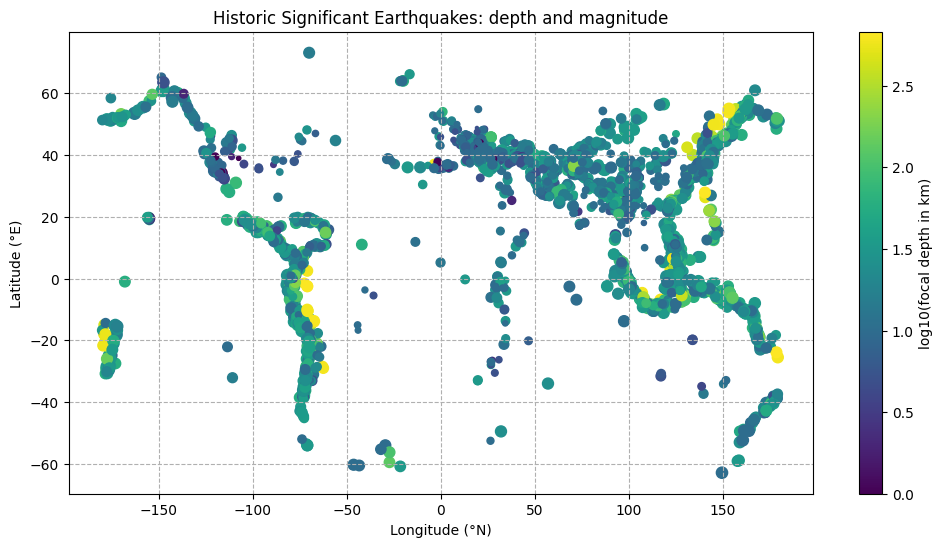

In [58]:
# Your solution here
# Hint: np.genfromtxt(path, delimiter="\t", skip_header=1) loads the whole file; every
#       non-numeric field becomes NaN, which is what you want here. Pull the four columns out
#       by position -- the focal depth, for example, is arr[:, 8]
edata = np.genfromtxt(path, delimiter="\t", skip_header=1)

focal_depth = edata[:, 8]
magnitude = edata[:, 9]
latitude = edata[:, 20]
longitude = edata[:, 21]

# Hint: keep only the rows where depth and magnitude are both above zero and latitude and
# longitude are not NaN. & combines two masks element-wise ("and"), and ~ flips one
#("not"), so ~np.isnan(latitude) is True wherever the latitude is present
mask = (focal_depth > 0) & (magnitude > 0) & (~np.isnan(latitude)) & (~np.isnan(longitude))

lon_filtered = longitude[mask]
lat_filtered = latitude[mask]
depth_filtered = focal_depth[mask]
mag_filtered = magnitude[mask]

#scatter plot
emap = plt.figure(figsize=(12, 6))
emap = plt.scatter(
    lon_filtered, lat_filtered,
    c=np.log10(depth_filtered), #colored points by log10 of focal depth
    s=mag_filtered ** 2) #setting point area to square of magnitude

# labeled colorbar
fig.colorbar(emap, label="log10(focal depth in km)")

#dotted grid
plt.grid(True, linestyle="--")

#axis labels
plt.title("Historic Significant Earthquakes: depth and magnitude")
plt.xlabel("Longitude (°N)")
plt.ylabel("Latitude (°E)")

plt.show()



# Hint: colour the points by np.log10 of the focal depth -- the base-10 logarithm, applied
#       element-wise, which spreads out depths from under a kilometre to several hundred --
#       and set the point area to the square of the magnitude

## Exercise 4: Antarctic sea ice, summer against winter

Two real snapshots of Antarctic sea ice concentration from NOAA/NSIDC are cached below, as
`path_winter` (1 August 2017) and `path_summer` (31 December 2017). Each holds
`seaice_conc_cdr`, the ice concentration as a fraction from 0 to 1, on a south polar
stereographic grid — its coordinates are 2D `latitude`/`longitude` arrays rather than simple 1D
dimensions, so xarray's own `.plot()` will not label it cleanly.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.4-target-seaice.png" alt="Two south polar stereographic maps of Antarctic sea ice concentration, one in austral winter with a wide ice ring and one in austral summer with much less ice" width="100%">

<em>The figure to replicate: the same field on the same projection at two dates, with the land drawn
in grey beneath the ice and one colorbar shared by both panels.</em>


Rebuild it, and say which date shows more ice.

In [59]:
# Pre-supplied: download the data files and cache them locally.
import pooch

path_winter = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/seaice_conc_daily_sh_f17_20170801_v03r01.nc",
    known_hash="sha256:1ff50bca1e6249a9b2fcd9d9466e31bdb5be650243f99c7319ab2ce625b87ce7",
    fname="seaice_conc_daily_sh_f17_20170801_v03r01.nc",
    path=pooch.os_cache("mlees"),
)
path_summer = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/seaice_conc_daily_sh_f17_20171231_v03r01.nc",
    known_hash="sha256:309418969ad09f42b8104589bcb86de4ed353a5742fef9385baec174c7d55e66",
    fname="seaice_conc_daily_sh_f17_20171231_v03r01.nc",
    path=pooch.os_cache("mlees"),
)

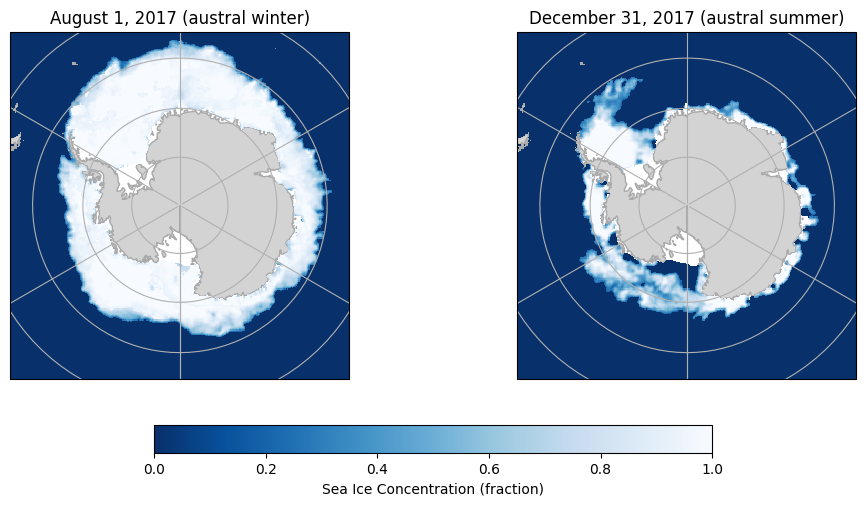

In [80]:
# Your solution here
# Hint: open each file with xr.open_dataset and select the single time step with .isel(time=0)
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

winterds = xr.open_dataset(path_winter)
summerds = xr.open_dataset(path_summer)

#selecting single time step with .isel(time=0)... whatever that means
winter_step = winterds.isel(time=0)
summer_step = summerds.isel(time=0)


# Hint: the valid concentration range is 0-1; a few cells carry flag values above 1
#       (land, coastal, missing) -- mask them out first with da.where(da <= 1)


#extracting sea ice concentration data arrays
winter_da = winter_step["seaice_conc_cdr"]
summer_da = summer_step["seaice_conc_cdr"]

#mask out flag values above 1 to constrain to valid concentration range
winter_masked = winter_da.where(winter_da <= 1)
summer_masked = summer_da.where(summer_da <= 1)


# Hint: build a figure with two ccrs.SouthPolarStereo() axes:
#       plt.subplots(1, 2, subplot_kw={"projection": ccrs.SouthPolarStereo()})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={"projection": ccrs.SouthPolarStereo()})

# Hint: ax.set_extent([-180, 180, -90, -55], ccrs.PlateCarree()) crops each axes to the
#       Southern Ocean instead of the whole hemisphere
ax1.set_extent([-180, 180, -90, -55], ccrs.PlateCarree())
ax2.set_extent([-180, 180, -90, -55], ccrs.PlateCarree())

#adding land feature under data
ax1.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="darkgray", zorder=1)
ax2.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="darkgray", zorder=1)

# Hint: since latitude/longitude are 2D, plot with
#       ax.pcolormesh(ds["longitude"], ds["latitude"], masked, transform=ccrs.PlateCarree())
#       rather than xarray's own .plot()
# Hint: pass vmin=0 and vmax=1 to both pcolormesh calls, so a colour means the same
#       concentration in both panels and one colorbar can serve both
pcm_winter = ax1.pcolormesh(winter_masked["longitude"], winter_masked["latitude"], winter_masked, transform=ccrs.PlateCarree(), vmin = 0, vmax = 1, cmap="Blues_r")
pcm_summer = ax2.pcolormesh(summer_masked["longitude"], summer_masked["latitude"], summer_masked, transform=ccrs.PlateCarree(), vmin = 0, vmax = 1, cmap="Blues_r")

#colorbar and gridlines
fig.colorbar(pcm_winter, ax=[ax1, ax2], orientation = "horizontal", label= "Sea Ice Concentration (fraction)", shrink=0.6, pad=0.1)
ax1.gridlines()
ax2.gridlines()

#titles
ax1.set_title("August 1, 2017 (austral winter)")
ax2.set_title("December 31, 2017 (austral summer)")

plt.show()


#
# Hint: add cfeature.LAND under the data and gridlines; fig.colorbar(pcm, ax=axes, label=...)
#       takes the whole array of axes and draws one colorbar for both panels

## Exercise 5: The 2014 earthquakes over North America

The file cached below is the real USGS earthquake catalog for 2014 — one row per event
worldwide, with latitude, longitude, depth and magnitude in columns 1 to 4. The target figure
keeps the whole catalog and lets the map extent do the selecting, so what you see is a window
onto a global dataset rather than one cropped to North America in advance.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.4-target-earthquakes-map.png" alt="A Robinson-projection map of North America with state boundaries, lakes and rivers, and earthquake locations coloured by depth" width="90%">

<em>The figure to replicate: magnitude 4 and above, on a Robinson projection cropped to North and
Central America, over land, ocean, lake, river and state-boundary features.</em>


Rebuild it.

In [61]:
# Pre-supplied: download the data file and cache it locally.
import pooch

path = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/usgs_earthquakes_2014.csv",
    known_hash="sha256:84d455fb96dc8f782fba4b5fbe56cb8970cab678f07c766fcba1b1c4674de1b1",
    fname="usgs_earthquakes_2014.csv",
    path=pooch.os_cache("mlees"),
)

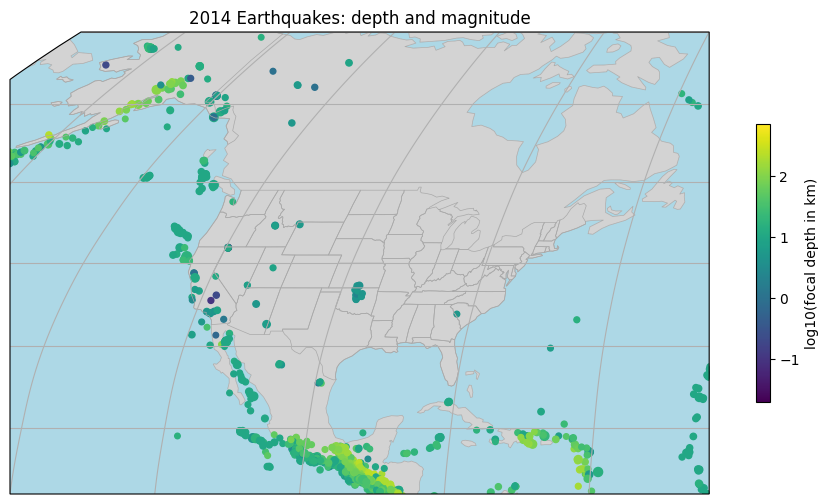

In [100]:
# Your solution here
# Hint: load the four numeric columns with
#       np.genfromtxt(path, delimiter=",", skip_header=1, usecols=(1, 2, 3, 4))
#       -- usecols skips the text columns (time, place, ...) mixed in with the numbers

quake_data = np.genfromtxt(path, delimiter=",", skip_header=1, usecols=(1, 2, 3, 4))
latitude = quake_data[:, 0]
longitude = quake_data[:, 1]
depth_km = quake_data[:, 2]
mag = quake_data[:, 3]


# Hint: keep mag >= 4 and depth_km > 0 (a few events are recorded at exactly 0 km, which
#       np.log10 cannot take); combine the two conditions into one mask with & ("and")

#extract mag and depth_km arrays and make mask
mask = (mag >= 4) & (depth_km > 0)

#filter by mask
lon_filtered = longitude[mask]
lat_filtered = latitude[mask]
depth_filtered = depth_km[mask]
mag_filtered = mag[mask]


# Hint: build a figure with a single ccrs.Robinson() projection
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": ccrs.Robinson()})
ax.set_extent([-140, -60, 12, 70], ccrs.PlateCarree())
quakemap = ax.scatter(lon_filtered, lat_filtered, transform=ccrs.PlateCarree(),c=np.log10(depth_filtered), s=mag_filtered ** 2)
#adding features
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor = "darkgray", linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor="darkgray", facecolor = "none")

#colorbar and gridlines
fig.colorbar(quakemap, label="log10(focal depth in km)", shrink = 0.6)
ax.gridlines()
ax.set_title("2014 Earthquakes: depth and magnitude")

plt.show()
#
# Hint: fig, ax = plt.subplots(subplot_kw={"projection": ccrs.Robinson()})
# Hint: ax.set_extent([-140, -60, 12, 70], ccrs.PlateCarree()) crops to the window shown
# Hint: the features are cfeature.LAND, cfeature.OCEAN, cfeature.LAKES, cfeature.RIVERS and
#       cfeature.STATES; add_feature takes edgecolor, facecolor and linewidth, and STATES
#       reads better in gray at a thin linewidth
# Hint: ax.scatter(longitude, latitude, transform=ccrs.PlateCarree(),
#                  c=np.log10(depth_km), s=mag ** 2)
#       -- transform tells cartopy the coordinates are plain lon/lat, not already projected
# Hint: finish with ax.gridlines, a labelled colorbar, and a title